# Task 6 — FAR/FRR vs threshold & ROC curve

Comprehensive threshold analysis:
- **FAR/FRR vs threshold** — find the operating point
- **ROC curve** — AUC, EER
- **Threshold justification** — compare candidate thresholds by use-case

Data source: `data/enrolled_test/` (genuine pairs) + impostor pairs sampled from the same set.

## 1. Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding
from src.database import EmbeddingDB
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED     = 44
TEST_DIR = Path('../data/enrolled_test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
user_list      = sorted(enrolled_users)
print(f'Enrolled users : {len(enrolled_users)}')

Loading model...
Enrolled users : 105


## 2. Build genuine + impostor score pairs

In [2]:
rng = random.Random(SEED)

scores_gen = []
scores_imp = []

for user_dir in sorted(d for d in TEST_DIR.iterdir()
                       if d.is_dir() and d.name in enrolled_users):
    user_id = user_dir.name
    refs    = db.get_user_embeddings(user_id)
    if not refs:
        continue

    for img_path in list_images(user_dir):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        emb = get_embedding(app, img, fallback=True)
        if emb is None:
            continue

        # Genuine
        scores_gen.append(max(float(np.dot(emb, r)) for r in refs))

        # Impostor
        for imp_id in rng.sample([u for u in user_list if u != user_id],
                               min(10, len(user_list) - 1)):
            imp_refs = db.get_user_embeddings(imp_id)
            if imp_refs:
                scores_imp.append(max(float(np.dot(emb, r)) for r in imp_refs))

scores = np.concatenate([scores_gen, scores_imp])
labels = np.concatenate([np.ones(len(scores_gen)), np.zeros(len(scores_imp))])

print(f'Genuine  pairs : {len(scores_gen)}')
print(f'Impostor pairs : {len(scores_imp)}')
print(f'Score range    : [{scores.min():.4f}, {scores.max():.4f}]')

Genuine  pairs : 2397
Impostor pairs : 23970
Score range    : [-0.2049, 0.9511]


## 3. ROC curve & EER

AUC : 0.9963
EER : 0.86%  at threshold = 0.1842


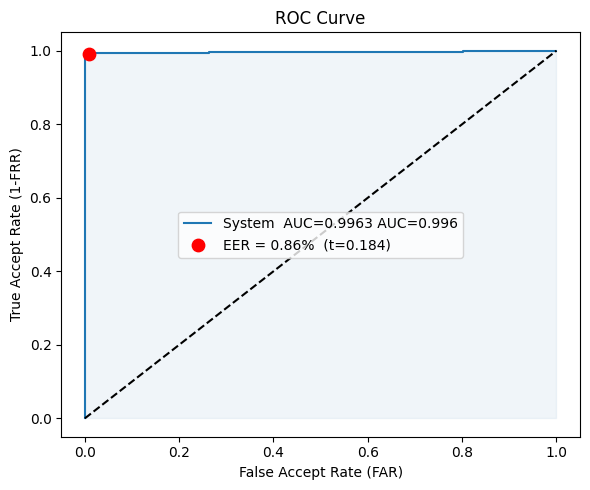

In [3]:
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_thresh  = eer(fpr, tpr, thresholds)
auc_val              = auc(fpr, tpr)

print(f'AUC : {auc_val:.4f}')
print(f'EER : {eer_val*100:.2f}%  at threshold = {eer_thresh:.4f}')

out_dir = Path('../results/task6')
out_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
plot_roc(fpr, tpr, ax=ax, label=f'System  AUC={auc_val:.4f}')
ax.scatter([eer_val], [1 - eer_val], color='red', zorder=5, s=80,
           label=f'EER = {eer_val*100:.2f}%  (t={eer_thresh:.3f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'roc.png', dpi=150)
plt.show()

## 4. FAR / FRR vs threshold

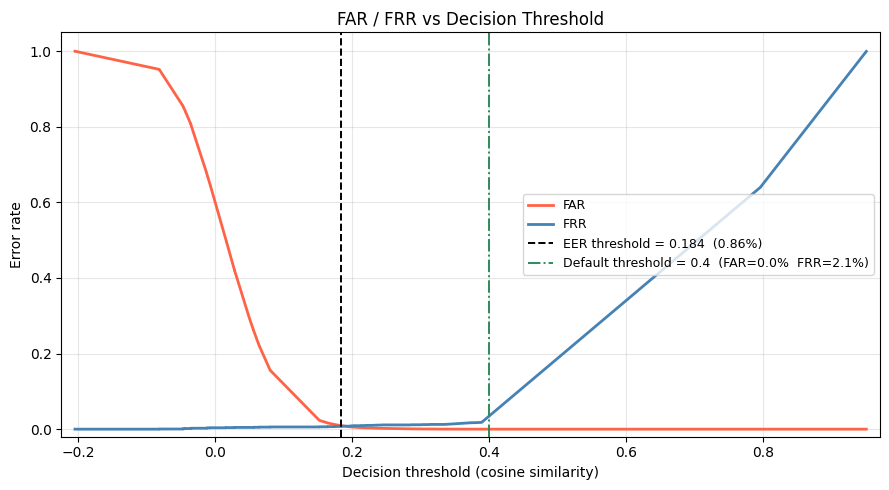

In [4]:
# Compute FAR and FRR at every threshold returned by sklearn
# (gives exact breakpoints, not just a coarse sweep)
frr_curve = 1 - tpr   # FRR = 1 - TPR
far_curve = fpr

fig, ax = plt.subplots(figsize=(9, 5))

# POPRAWKA: Usunięto [:-1] z far_curve i frr_curve
ax.plot(thresholds, far_curve, color='tomato',    lw=2, label='FAR')
ax.plot(thresholds, frr_curve, color='steelblue', lw=2, label='FRR')

ax.axvline(eer_thresh, color='black', ls='--', lw=1.4,
           label=f'EER threshold = {eer_thresh:.3f}  ({eer_val*100:.2f}%)')

# Highlight the default operating threshold
DEFAULT_THRESH = 0.4
far_def, frr_def, acc_def = compute_far_frr(scores, labels, DEFAULT_THRESH)
ax.axvline(DEFAULT_THRESH, color='seagreen', ls='-.', lw=1.4,
           label=f'Default threshold = {DEFAULT_THRESH}  '
                 f'(FAR={far_def*100:.1f}%  FRR={frr_def*100:.1f}%)')

ax.set_xlabel('Decision threshold (cosine similarity)')
ax.set_ylabel('Error rate')
ax.set_title('FAR / FRR vs Decision Threshold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(scores.min() - 0.02, scores.max() + 0.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig(out_dir / 'far_frr_vs_threshold.png', dpi=150)
plt.show()

## 5. Candidate thresholds comparison

,Strategy,Threshold,FAR (%),FRR (%),Accuracy (%)
0,High security (FRR ≤ 5%),0.389200,0.000000,1.790000,99.840000
1,EER (balanced),0.184200,0.920000,0.790000,99.090000
2,Default (0.4),0.400000,0.000000,2.090000,99.810000
3,High convenience (FAR ≤ 5%),0.152200,2.320000,0.580000,97.840000


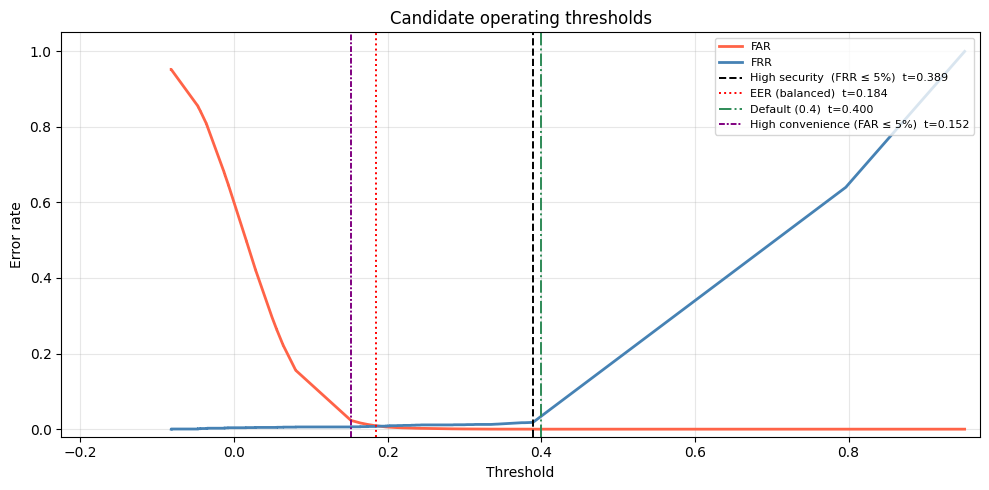

In [5]:
# Compare several candidate thresholds side by side
# Low FAR threshold  — security-critical: minimise false accepts
# EER threshold      — balanced: FAR ≈ FRR
# Default threshold  — current system setting
# Low FRR threshold  — convenience-critical: minimise false rejects

# Find threshold minimising FAR while keeping FRR < 0.20
frr_arr = frr_curve[:-1]
far_arr = far_curve[:-1]
thr_arr = thresholds[:-1]

# Max threshold where FRR <= 0.05 (high security)
mask_sec = frr_arr <= 0.05
t_high_security = float(thr_arr[mask_sec].max()) if mask_sec.any() else float(thr_arr[-1])
far_hs, frr_hs, acc_hs = compute_far_frr(scores, labels, t_high_security)

# Min threshold where FAR <= 0.05 (high convenience)
mask_conv = far_arr <= 0.05
t_high_conv = float(thr_arr[mask_conv].min()) if mask_conv.any() else float(thr_arr[0])
far_hc, frr_hc, acc_hc = compute_far_frr(scores, labels, t_high_conv)

candidates = [
    ('High security  (FRR ≤ 5%)', t_high_security, far_hs, frr_hs, acc_hs),
    ('EER (balanced)',             eer_thresh,      *compute_far_frr(scores, labels, eer_thresh)[:3]),
    ('Default (0.4)',              DEFAULT_THRESH,  far_def, frr_def, acc_def),
    ('High convenience (FAR ≤ 5%)',t_high_conv,    far_hc, frr_hc, acc_hc),
]

rows = []
for name, t, far, frr, acc in candidates:
    rows.append({
        'Strategy': name,
        'Threshold': round(t, 4),
        'FAR (%)':   round(far * 100, 2),
        'FRR (%)':   round(frr * 100, 2),
        'Accuracy (%)': round(acc * 100, 2),
    })

df = pd.DataFrame(rows)
display(df.style
          .highlight_min(subset=['FAR (%)'],      color='#d9ead3')
          .highlight_min(subset=['FRR (%)'],      color='#cfe2f3')
          .highlight_max(subset=['Accuracy (%)'], color='#fff2cc'))

# Mark candidates on the FAR/FRR plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_arr, far_arr, color='tomato',    lw=2, label='FAR')
ax.plot(thr_arr, frr_arr, color='steelblue', lw=2, label='FRR')

colors_cand = ['black', 'red', 'seagreen', 'purple']
styles_cand = ['--', ':', '-.', (0, (3,1,1,1))]
for (name, t, far, frr, acc), col, ls in zip(candidates, colors_cand, styles_cand):
    ax.axvline(t, color=col, ls=ls, lw=1.4, label=f'{name}  t={t:.3f}')

ax.set_xlabel('Threshold')
ax.set_ylabel('Error rate')
ax.set_title('Candidate operating thresholds')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(scores.min() - 0.02, scores.max() + 0.02)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig(out_dir / 'candidate_thresholds.png', dpi=150)
plt.show()

## 6. Score distributions with threshold markers

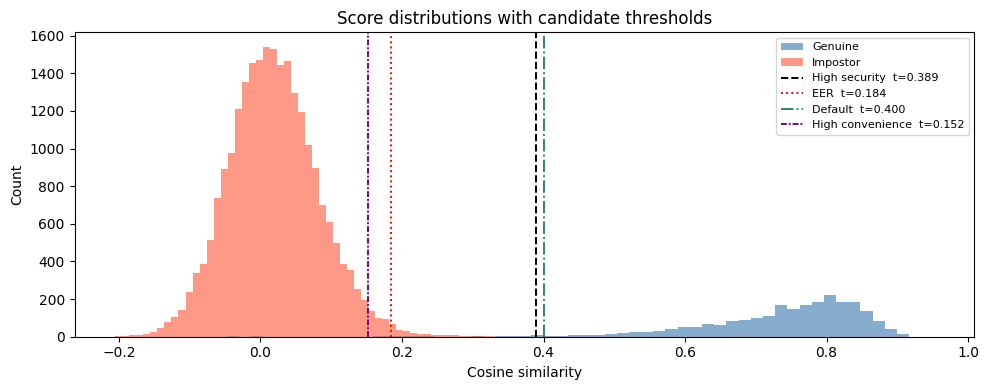

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_gen, bins=60, alpha=0.65, color='steelblue', label='Genuine')
ax.hist(scores_imp, bins=60, alpha=0.65, color='tomato',    label='Impostor')

for (name, t, *_), col, ls in zip(candidates, colors_cand, styles_cand):
    ax.axvline(t, color=col, ls=ls, lw=1.4, label=f'{name.split("(")[0].strip()}  t={t:.3f}')

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Score distributions with candidate thresholds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(out_dir / 'score_distributions_thresholds.png', dpi=150)
plt.show()

## 7. Threshold justification

The choice of operating threshold depends on the application context.
Below is a data-driven justification based on the measured curves.

In [7]:
print('=== THRESHOLD JUSTIFICATION ===')
print()
print(f'AUC  = {auc_val:.4f}  — classifier quality (1.0 = perfect)')
print(f'EER  = {eer_val*100:.2f}%  at t = {eer_thresh:.4f}')
print()
print('Candidate thresholds:')
print(f'  t = {t_high_security:.4f}  [High security]')
print(f'        FAR = {far_hs*100:.2f}%  FRR = {frr_hs*100:.2f}%  Acc = {acc_hs*100:.2f}%')
print(f'        Use when false accepts are costly (e.g. physical access control).')
print()
print(f'  t = {eer_thresh:.4f}  [EER — balanced]')
far_e, frr_e, acc_e = compute_far_frr(scores, labels, eer_thresh)
print(f'        FAR = {far_e*100:.2f}%  FRR = {frr_e*100:.2f}%  Acc = {acc_e*100:.2f}%')
print(f'        Use when both error types carry equal cost.')
print()
print(f'  t = {DEFAULT_THRESH:.4f}  [Default — current system]')
print(f'        FAR = {far_def*100:.2f}%  FRR = {frr_def*100:.2f}%  Acc = {acc_def*100:.2f}%')
print(f'        Manually chosen starting point; adjust based on deployment context.')
print()
print(f'  t = {t_high_conv:.4f}  [High convenience]')
print(f'        FAR = {far_hc*100:.2f}%  FRR = {frr_hc*100:.2f}%  Acc = {acc_hc*100:.2f}%')
print(f'        Use when false rejects are costly (e.g. user-facing authentication).')
print()
print('Recommended operating threshold:')
# Pick the threshold closest to EER but with FAR <= FRR (favour security)
rec_thresh = eer_thresh
rec_far, rec_frr, rec_acc = compute_far_frr(scores, labels, rec_thresh)
print(f'  t = {rec_thresh:.4f}  (EER point)  '
      f'FAR={rec_far*100:.2f}%  FRR={rec_frr*100:.2f}%  Acc={rec_acc*100:.2f}%')
print()
print('Reasoning:')
print('  The EER threshold provides a balanced trade-off and is commonly used')
print('  as the default operating point in academic evaluations. For production')
print('  use, shift toward the high-security threshold to limit unauthorized access.')

=== THRESHOLD JUSTIFICATION ===

AUC  = 0.9963  — classifier quality (1.0 = perfect)
EER  = 0.86%  at t = 0.1842

Candidate thresholds:
  t = 0.3892  [High security]
        FAR = 0.00%  FRR = 1.79%  Acc = 99.84%
        Use when false accepts are costly (e.g. physical access control).

  t = 0.1842  [EER — balanced]
        FAR = 0.92%  FRR = 0.79%  Acc = 99.09%
        Use when both error types carry equal cost.

  t = 0.4000  [Default — current system]
        FAR = 0.00%  FRR = 2.09%  Acc = 99.81%
        Manually chosen starting point; adjust based on deployment context.

  t = 0.1522  [High convenience]
        FAR = 2.32%  FRR = 0.58%  Acc = 97.84%
        Use when false rejects are costly (e.g. user-facing authentication).

Recommended operating threshold:
  t = 0.1842  (EER point)  FAR=0.92%  FRR=0.79%  Acc=99.09%

Reasoning:
  The EER threshold provides a balanced trade-off and is commonly used
  as the default operating point in academic evaluations. For production
  use, sh

## 8. Summary

In [8]:
print('=' * 60)
print('TASK 6 — ROC / THRESHOLD ANALYSIS')
print('=' * 60)
print(f'  Genuine pairs  : {len(scores_gen)}')
print(f'  Impostor pairs : {len(scores_imp)}')
print(f'  AUC            : {auc_val:.4f}')
print(f'  EER            : {eer_val*100:.2f}%  (t = {eer_thresh:.4f})')
print()
print(f'  {"Strategy":<30} {"Threshold":>10} {"FAR":>8} {"FRR":>8} {"Acc":>8}')
print('  ' + '-' * 66)
for name, t, far, frr, acc in candidates:
    print(f'  {name:<30} {t:>10.4f} {far*100:>7.2f}% {frr*100:>7.2f}% {acc*100:>7.2f}%')
print('=' * 60)

TASK 6 — ROC / THRESHOLD ANALYSIS
  Genuine pairs  : 2397
  Impostor pairs : 23970
  AUC            : 0.9963
  EER            : 0.86%  (t = 0.1842)

  Strategy                        Threshold      FAR      FRR      Acc
  ------------------------------------------------------------------
  High security  (FRR ≤ 5%)          0.3892    0.00%    1.79%   99.84%
  EER (balanced)                     0.1842    0.92%    0.79%   99.09%
  Default (0.4)                      0.4000    0.00%    2.09%   99.81%
  High convenience (FAR ≤ 5%)        0.1522    2.32%    0.58%   97.84%
